In [23]:
import numpy as np
from PIL import Image
from src.dataset import data as dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from matplotlib import pyplot as plt

In [18]:
transform = transforms.Compose([
    transforms.Resize((384, 384)),  # Resize images to a uniform size
    transforms.ToTensor(),           # Convert PIL images to tensors
])

In [19]:
l_train_dataset = dataset('IDRID', 'IDRID/train_data.npy', transform_fn=transform)
val_dataset = dataset('IDRID', 'IDRID/val_data.npy', transform_fn=transform)
test_dataset = dataset('IDRID', 'IDRID/test_data.npy', transform_fn=transform)

In [20]:
print('Created dataset')
print("labeled data : {}, training data : {}".format(
len(l_train_dataset), len(l_train_dataset)))
print("validation data : {}, test data : {}".format(len(val_dataset), len(test_dataset)))

Created dataset
labeled data : 206, training data : 206
validation data : 207, test data : 103


In [21]:
l_loader = DataLoader(l_train_dataset, 32, shuffle=True, drop_last=True, num_workers=8)
val_loader = DataLoader(val_dataset, 128, shuffle=False, drop_last=False, num_workers=8)
test_loader = DataLoader(test_dataset, 128, shuffle=False, drop_last=False, num_workers=8)

In [22]:
def test_data_loader(loader, loader_name):
    print(f"Testing {loader_name}:")
    for batch_idx, (data, target) in enumerate(loader):
        print(f"Batch {batch_idx + 1} - Data shape: {data.shape}, Target shape: {target.shape}")
        if batch_idx >= 1:  # Limit to first 2 batches for brevity
            break

# Test each DataLoader
test_data_loader(l_loader, "l_loader")
test_data_loader(val_loader, "val_loader")
test_data_loader(test_loader, "test_loader")

Testing l_loader:
Batch 1 - Data shape: torch.Size([32, 1, 384, 384]), Target shape: torch.Size([32])
Batch 2 - Data shape: torch.Size([32, 1, 384, 384]), Target shape: torch.Size([32])
Testing val_loader:
Batch 1 - Data shape: torch.Size([128, 1, 384, 384]), Target shape: torch.Size([128])
Batch 2 - Data shape: torch.Size([79, 1, 384, 384]), Target shape: torch.Size([79])
Testing test_loader:
Batch 1 - Data shape: torch.Size([103, 1, 384, 384]), Target shape: torch.Size([103])


Visualizing l_loader:


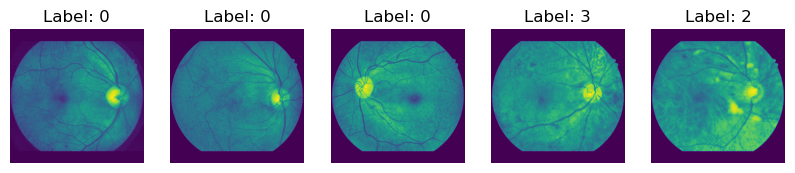

Visualizing val_loader:


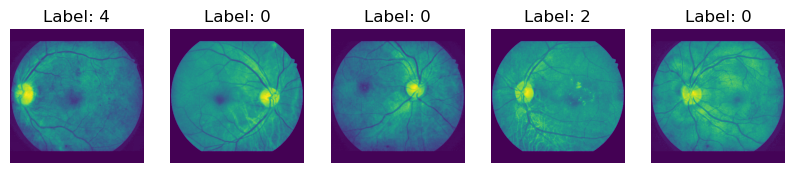

Visualizing test_loader:


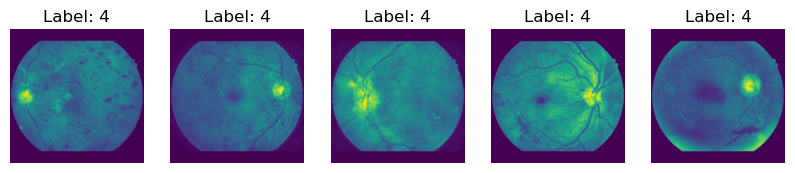

In [24]:
def visualize_data_loader(loader, loader_name, num_images=5):
    print(f"Visualizing {loader_name}:")
    data_iter = iter(loader)
    images, labels = next(data_iter)  # Get the first batch
    images = images[:num_images]  # Take only the first few images for visualization
    labels = labels[:num_images]  # Take corresponding labels

    # Create a grid of images
    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())  # Convert (C, H, W) to (H, W, C)
        plt.title(f'Label: {labels[i].item()}')  # Display label
        plt.axis('off')
    plt.show()

# Visualize images from each DataLoader
visualize_data_loader(l_loader, "l_loader")
visualize_data_loader(val_loader, "val_loader")
visualize_data_loader(test_loader, "test_loader")